In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Use TensorFlow‑Keras to avoid protobuf conflicts
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Conv2D, MaxPool2D, Flatten
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.optimizers import RMSprop

# Load training CSV
train_dir = pd.read_csv("../input/train.csv")
print("Train rows:", train_dir.shape[0])




2026-05-05 00:13:28.661630: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1777940008.674266      55 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1777940008.678321      55 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-05-05 00:13:28.693595: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

Train rows: 14175


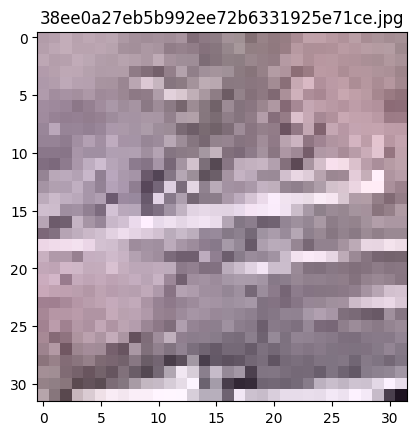

Image shape: (32, 32, 3)


In [2]:
# Visual sanity check
sample_id = train_dir.iloc[100, 0]
img = plt.imread(f"../input/train/{sample_id}")
plt.imshow(img)
plt.title(sample_id)
plt.show()
print("Image shape:", img.shape)




In [3]:
# Basic stats
print(train_dir.describe())




         has_cactus
count  14175.000000
mean       0.749771
std        0.433160
min        0.000000
25%        0.000000
50%        1.000000
75%        1.000000
max        1.000000


In [4]:
# Prepare training data
y_train = train_dir["has_cactus"].values
num_samples = len(train_dir)
X_train = np.zeros((num_samples, 32, 32, 3), dtype=np.float32)

for idx, filename in enumerate(train_dir["id"]):
    img_path = f"../input/train/{filename}"
    X_train[idx] = plt.imread(img_path)

X_train_scaled = X_train / 255.0
print("X_train shape:", X_train_scaled.shape)




X_train shape: (14175, 32, 32, 3)


In [5]:
# Build the CNN (unchanged architecture)
cactus = Sequential()
cactus.add(
    Conv2D(32, (5, 5), activation="relu", padding="same", input_shape=(32, 32, 3))
)
cactus.add(Conv2D(32, (5, 5), activation="relu", padding="same"))
cactus.add(MaxPool2D(pool_size=(2, 2)))
cactus.add(Dropout(0.2))

cactus.add(Conv2D(64, (3, 3), activation="relu", padding="same"))
cactus.add(Conv2D(64, (3, 3), activation="relu", padding="same"))
cactus.add(MaxPool2D(pool_size=(2, 2), strides=(2, 2)))
cactus.add(Dropout(0.2))

cactus.add(Flatten())
cactus.add(Dense(256, activation="relu"))
cactus.add(Dropout(0.5))
cactus.add(Dense(1, activation="sigmoid"))

# Optimizer uses learning_rate argument (not lr)
opt = RMSprop(learning_rate=0.001, rho=0.9, epsilon=1e-08, decay=0.0)

# Callbacks
lrreduce = ReduceLROnPlateau(
    monitor="val_accuracy", patience=3, verbose=1, factor=0.5, min_lr=1e-5
)
estop = EarlyStopping(monitor="val_accuracy", patience=5, restore_best_weights=True)

cactus.compile(optimizer=opt, loss="binary_crossentropy", metrics=["accuracy"])
cactus.summary()




/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
2026-05-05 00:13:43.209498: W tensorflow/core/common_runtime/gpu/gpu_bfc_allocator.cc:47] Overriding orig_value setting because the TF_FORCE_GPU_ALLOW_GROWTH environment variable is set. Original config value was 0.
I0000 00:00:1777940023.209944      55 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 46866 MB memory:  -> device: 0, name: NVIDIA RTX A6000, pci bus id: 0000:45:00.0, compute capability: 8.6
/usr/local/lib/python3.11/dist-packages/keras/src/optimizers/base_optimizer.py:86: UserWarning: Argument `decay` is no longer supported and will be ignored.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 32, 32, 32)     │         2,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 32, 32, 32)     │        25,632 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 16, 16, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     1,048,832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,132,577 (4.32 MB)

 Trainable params: 1,132,577 (4.32 MB)

 Non-trainable params: 0 (0.00 B)

In [6]:
# Train the model
cactus.fit(
    X_train_scaled,
    y_train,
    validation_split=0.15,
    epochs=30,
    batch_size=100,
    callbacks=[lrreduce, estop],
    verbose=1,
)




Epoch 1/30


I0000 00:00:1777940024.763707     108 service.cc:148] XLA service 0x7f658800cac0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1777940024.763735     108 service.cc:156]   StreamExecutor device (0): NVIDIA RTX A6000, Compute Capability 8.6
2026-05-05 00:13:44.791846: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:268] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1777940024.911861     108 cuda_dnn.cc:529] Loaded cuDNN version 90300


 43/121 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7360 - loss: 0.7759

I0000 00:00:1777940027.110397     108 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


121/121 ━━━━━━━━━━━━━━━━━━━━ 6s 26ms/step - accuracy: 0.7424 - loss: 0.6672 - val_accuracy: 0.8919 - val_loss: 0.2886 - learning_rate: 0.0010
Epoch 2/30
121/121 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8147 - loss: 0.3868 - val_accuracy: 0.9318 - val_loss: 0.1821 - learning_rate: 0.0010
Epoch 3/30
121/121 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9125 - loss: 0.2241 - val_accuracy: 0.9299 - val_loss: 0.2017 - learning_rate: 0.0010
Epoch 4/30
121/121 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9423 - loss: 0.1666 - val_accuracy: 0.9252 - val_loss: 0.1789 - learning_rate: 0.0010
Epoch 5/30
121/121 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9500 - loss: 0.1359 - val_accuracy: 0.9619 - val_loss: 0.1621 - learning_rate: 0.0010
Epoch 6/30
121/121 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9593 - loss: 0.1100 - val_accuracy: 0.9798 - val_loss: 0.0533 - learning_rate: 0.0010
Epoch 7/30
121/121 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9705 - loss: 0.0925 - val_accura

In [7]:
# Load test images
def read_in_test(test_dir):
    file_names = []
    # Pre‑allocate based on known test size (3325)
    out_array = np.zeros((3325, 32, 32, 3), dtype=np.float32)
    idx = 0
    for fname in sorted(os.listdir(test_dir)):
        if fname.lower().endswith(".jpg"):
            file_names.append(fname)
            img_path = os.path.join(test_dir, fname)
            out_array[idx] = plt.imread(img_path)
            idx += 1
    return out_array[:idx] / 255.0, file_names


X_test, fileid = read_in_test("../input/test")
print("Test samples loaded:", X_test.shape[0])




Test samples loaded: 3325


In [8]:
# Predict probabilities
probs = cactus.predict(X_test, batch_size=100).ravel()
print("Predictions shape:", probs.shape)




34/34 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step
Predictions shape: (3325,)


In [9]:
# Create submission – keep probabilities (no hard threshold)
sub = pd.DataFrame({"id": fileid, "has_cactus": probs})
sub.head()




,id,has_cactus
0,002930423b9840e67e5a54afd4768a1e.jpg,1.000000e+00
1,00351838ebf6dff6e53056e00a1e307c.jpg,1.000000e+00
2,003ec9bcef67171ba49fe4c3b7c80aec.jpg,1.000000e+00
3,0051207eb794887c619341090de84b50.jpg,2.602743e-06
4,0057728c8522c4881af60c3105b6492e.jpg,1.774919e-08


In [10]:
# Write submission file
sub.to_csv("cactus_submission.csv", index=False)
print("Submission saved to cactus_submission.csv with", len(sub), "rows.")

Submission saved to cactus_submission.csv with 3325 rows.
